In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import RFE
from joblib import dump
%matplotlib inline

In [2]:
# Charger le jeu de données
df = pd.read_csv(r"C:\\Users\\zizou\\OneDrive\\Desktop\\stage 3ème\\day 2\\csvfiles\\dataframefinale.csv", sep=';', encoding='utf-8-sig')

# Créer des caractéristiques dérivées
df['Taux_NombreTitres'] = df['Taux'] * df['Nombre de Titres']
df['Montant_Log'] = np.log1p(df['Montant'])  # Transformation logarithmique
df['NombreTitres_Log'] = np.log1p(df['Nombre de Titres'])

# Définir les caractéristiques et la cible
features = ['Nombre de Titres', 'Echéance', 'Taux', 'Jour', 'Mois', 'NumeroSemaine', 'Trimestre', 'JourSemaineNum', 'Taux_NombreTitres', 'NombreTitres_Log']
X = df[features]
y = df['Montant']

# Diviser les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fonction pour calculer le RMSE
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


=== Importance des Caractéristiques (Forêt Aléatoire) ===
             Feature  Importance
0   Nombre de Titres    0.314562
9   NombreTitres_Log    0.273787
2               Taux    0.149143
8  Taux_NombreTitres    0.079450
1           Echéance    0.067061
5      NumeroSemaine    0.052874
3               Jour    0.025813
4               Mois    0.021212
7     JourSemaineNum    0.012326
6          Trimestre    0.003771
Top 6 caractéristiques : ['Nombre de Titres', 'NombreTitres_Log', 'Taux', 'Taux_NombreTitres', 'Echéance', 'NumeroSemaine']


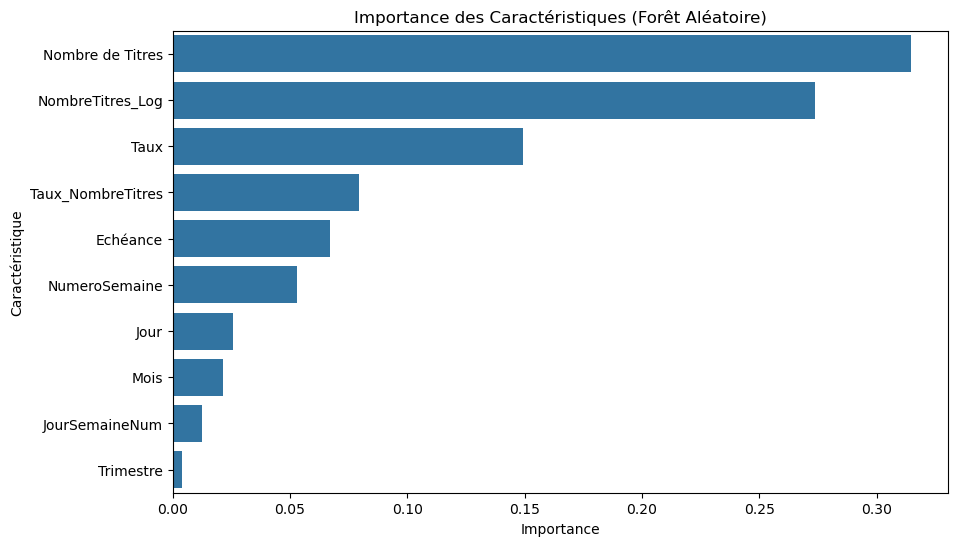

In [3]:
# Entraîner une Forêt Aléatoire pour obtenir l'importance des caractéristiques
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Obtenir l'importance des caractéristiques
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\n=== Importance des Caractéristiques (Forêt Aléatoire) ===")
print(feature_importance)

# Sélectionner les 6 caractéristiques les plus importantes
top_features = feature_importance['Feature'].head(6).tolist()
print(f"Top 6 caractéristiques : {top_features}")

# Mettre à jour les ensembles de données avec les caractéristiques sélectionnées
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# Visualiser l'importance des caractéristiques
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Importance des Caractéristiques (Forêt Aléatoire)')
plt.xlabel('Importance')
plt.ylabel('Caractéristique')
plt.show()

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [5]:
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42)
}

results = []
print("\n=== Entraînement Initial et RMSE ===")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = calculate_rmse(y_test, y_pred)
    results.append({'Model': name, 'Step': 'Initial', 'RMSE': rmse})
    print(f"{name} RMSE: {rmse:.4f}")


=== Entraînement Initial et RMSE ===
Random Forest RMSE: 3.8081
Gradient Boosting RMSE: 4.8980
Extra Trees RMSE: 4.0316


In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    },
    'Extra Trees': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
}

print("\n=== Ajustement Optimisé des Hyperparamètres et RMSE ===")
best_models = {}
for name, model in models.items():
    random_search = RandomizedSearchCV(
        model,
        param_distributions[name],
        n_iter=10,  # Tester 10 combinaisons aléatoires par modèle
        cv=3,  # Réduire à 3 plis
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
    random_search.fit(X_train_scaled, y_train)
    best_model = random_search.best_estimator_
    best_models[name] = best_model
    y_pred = best_model.predict(X_test_scaled)
    rmse = calculate_rmse(y_test, y_pred)
    results.append({'Model': name, 'Step': 'Tuned', 'RMSE': rmse})
    print(f"{name} RMSE (Ajusté): {rmse:.4f}")
    print(f"Meilleurs paramètres pour {name}: {random_search.best_params_}")


=== Ajustement Optimisé des Hyperparamètres et RMSE ===
Random Forest RMSE (Ajusté): 3.8078
Meilleurs paramètres pour Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


c:\Users\zizou\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Gradient Boosting RMSE (Ajusté): 3.8294
Meilleurs paramètres pour Gradient Boosting: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Extra Trees RMSE (Ajusté): 3.9913
Meilleurs paramètres pour Extra Trees: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': None}


In [9]:
print("\n=== Validation Croisée (5-fold) ===")
for name, model in best_models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    results.append({'Model': name, 'Step': 'Cross-Validation', 'RMSE': cv_rmse.mean()})
    print(f"{name} RMSE (Validation Croisée): Moyenne = {cv_rmse.mean():.4f}, Écart-type = {cv_rmse.std():.4f}")


=== Validation Croisée (5-fold) ===
Random Forest RMSE (Validation Croisée): Moyenne = 3.5842, Écart-type = 0.2323
Gradient Boosting RMSE (Validation Croisée): Moyenne = 3.6080, Écart-type = 0.0702
Extra Trees RMSE (Validation Croisée): Moyenne = 3.6303, Écart-type = 0.1288


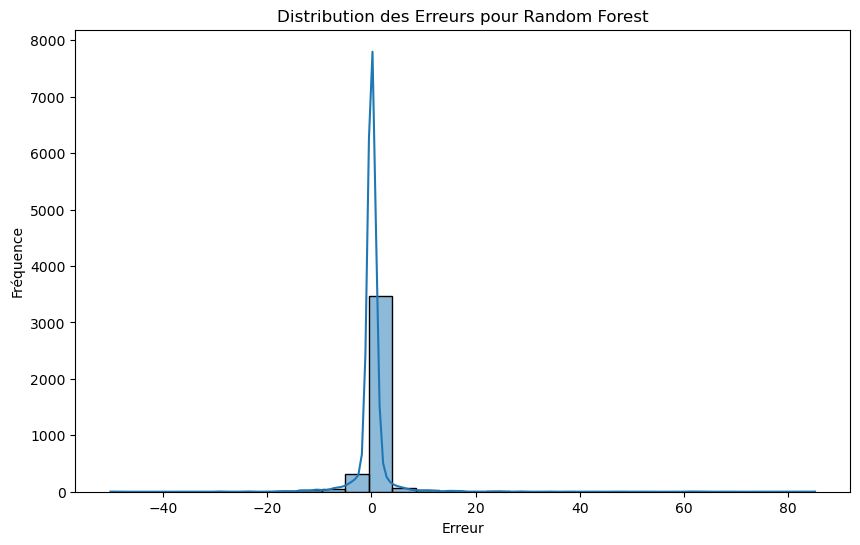


=== Top 5 Prédictions avec les Plus Grandes Erreurs ===
       Valeur Réelle  Valeur Prédite     Erreur  Erreur Absolue
3999          96.527       11.353935  85.173065       85.173065
7449          98.611       30.595305  68.015695       68.015695
19956        100.000       38.153280  61.846720       61.846720
14095         83.000       21.756040  61.243960       61.243960
16769         59.999        8.293180  51.705820       51.705820


In [10]:
# Analyser les erreurs pour le meilleur modèle (par exemple, Forêt Aléatoire)
best_model_name = min(results, key=lambda x: x['RMSE'] if x['Step'] == 'Tuned' else float('inf'))['Model']
best_model = best_models[best_model_name]
y_pred = best_model.predict(X_test_scaled)

# Créer un DataFrame pour les erreurs
errors = pd.DataFrame({
    'Valeur Réelle': y_test,
    'Valeur Prédite': y_pred,
    'Erreur': y_test - y_pred
})
errors['Erreur Absolue'] = errors['Erreur'].abs()

# Visualiser la distribution des erreurs
plt.figure(figsize=(10, 6))
sns.histplot(errors['Erreur'], bins=30, kde=True)
plt.title(f'Distribution des Erreurs pour {best_model_name}')
plt.xlabel('Erreur')
plt.ylabel('Fréquence')
plt.show()

# Identifier les prédictions avec les plus grandes erreurs
print("\n=== Top 5 Prédictions avec les Plus Grandes Erreurs ===")
print(errors.sort_values(by='Erreur Absolue', ascending=False).head())

In [11]:
dump(best_models[best_model_name], r"C:\\Users\\zizou\\OneDrive\\Desktop\\stage 3ème\\day 2\\best_model_optimized.joblib")
print(f"✅ Meilleur modèle ({best_model_name}) sauvegardé sous best_model_optimized.joblib")

✅ Meilleur modèle (Random Forest) sauvegardé sous best_model_optimized.joblib



=== Résumé des Résultats RMSE ===
Step               Cross-Validation   Initial     Tuned
Model                                                  
Extra Trees                3.630308  4.031642  3.991277
Gradient Boosting          3.608014  4.898043  3.829354
Random Forest              3.584220  3.808110  3.807757


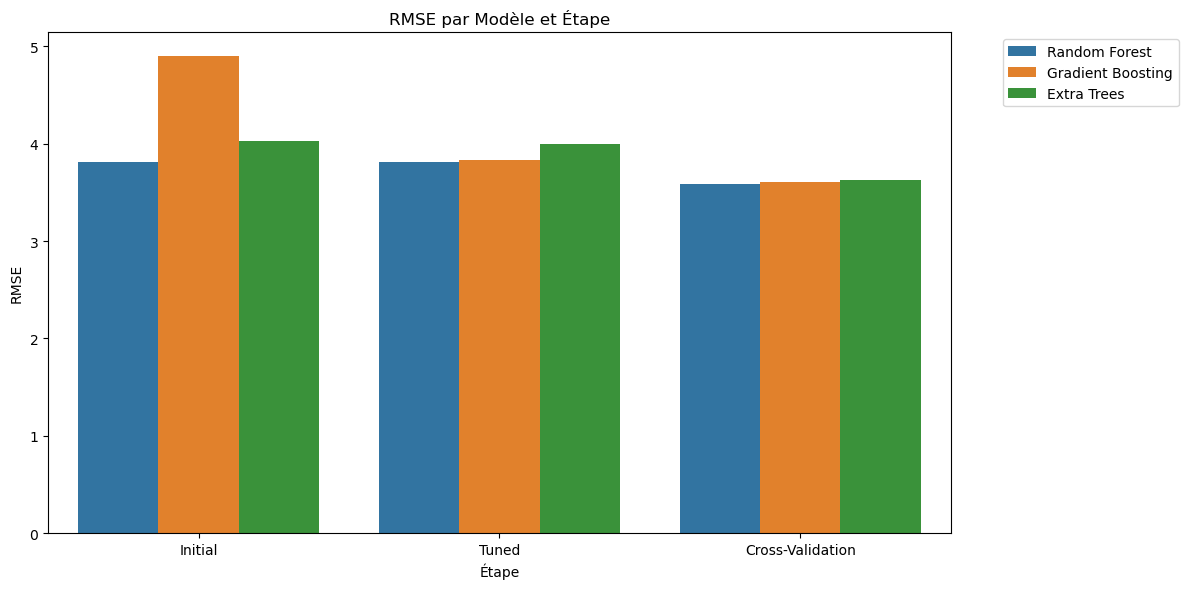

✅ Résultats sauvegardés sous optimized_modeling_results.csv


In [12]:
results_df = pd.DataFrame(results)
print("\n=== Résumé des Résultats RMSE ===")
print(results_df.pivot(index='Model', columns='Step', values='RMSE'))

# Visualiser les résultats
plt.figure(figsize=(12, 6))
sns.barplot(x='Step', y='RMSE', hue='Model', data=results_df)
plt.title('RMSE par Modèle et Étape')
plt.ylabel('RMSE')
plt.xlabel('Étape')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Sauvegarder les résultats
results_df.to_csv(r"C:\\Users\\zizou\\OneDrive\\Desktop\\stage 3ème\\day 2\\csvfiles\\optimized_modeling_results.csv", index=False, sep=';', encoding='utf-8-sig')
print("✅ Résultats sauvegardés sous optimized_modeling_results.csv")